### Mount Google Drive and Load the Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/archive.zip'

# Create a directory to extract the contents
extraction_path = 'dataset'
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Archive extracted to: {extraction_path}")
print("Contents of the extracted directory:")
print(os.listdir(extraction_path))

Archive extracted to: dataset
Contents of the extracted directory:
['split_dataset']


In [3]:
import json
from PIL import Image # Pillow library for reading image dimensions

def yolo_to_coco_conversion(yolo_labels_dir, images_dir, output_coco_json_path, category_mapping):
    """
    Converts YOLO format labels to COCO format.

    Args:
        yolo_labels_dir (str): Path to the directory containing YOLO .txt label files.
        images_dir (str): Path to the directory containing corresponding image files.
        output_coco_json_path (str): Path to save the output COCO JSON file.
        category_mapping (dict): A dictionary mapping YOLO class IDs (int) to COCO category dicts
                                 (e.g., {0: {'id': 1, 'name': 'my_class1'}, 1: {'id': 2, 'name': 'my_class2'}}).
    """

    coco_output = {
        "info": {},
        "licenses": [],
        "categories": list(category_mapping.values()),
        "images": [],
        "annotations": []
    }

    image_id_counter = 0
    annotation_id_counter = 0

    print(f"Starting conversion from {yolo_labels_dir} to COCO format...")

    label_files = [f for f in os.listdir(yolo_labels_dir) if f.endswith('.txt')]
    if not label_files:
        print(f"No YOLO label files found in {yolo_labels_dir}. Please check the path.")
        return

    for label_file in label_files:
        yolo_path = os.path.join(yolo_labels_dir, label_file)

        # Infer image file path from label file path
        # Assuming image and label files have the same base name but different extensions
        base_filename = os.path.splitext(label_file)[0]

        image_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
            potential_image_path = os.path.join(images_dir, base_filename + ext)
            if os.path.exists(potential_image_path):
                image_path = potential_image_path
                break

        if not image_path:
            print(f"Warning: Could not find image for label {label_file}. Skipping.")
            continue

        try:
            with Image.open(image_path) as img:
                width, height = img.size
        except Exception as e:
            print(f"Error opening image {image_path}: {e}. Skipping.")
            continue

        image_id_counter += 1
        coco_output["images"].append({
            "id": image_id_counter,
            "file_name": os.path.basename(image_path),
            "width": width,
            "height": height
        })

        with open(yolo_path, 'r') as f:
            for line in f.readlines():
                line = line.strip().split(' ')
                if not line:
                    continue

                class_id_yolo = int(line[0])
                x_center_norm, y_center_norm, width_norm, height_norm = map(float, line[1:])

                # Convert YOLO (normalized center_x, center_y, width, height) to COCO (x_top_left, y_top_left, width, height)
                x_center = x_center_norm * width
                y_center = y_center_norm * height
                bbox_width = width_norm * width
                bbox_height = height_norm * height

                x_top_left = x_center - (bbox_width / 2)
                y_top_left = y_center - (bbox_height / 2)

                # Ensure bounding box coordinates are within image boundaries
                x_top_left = max(0, x_top_left)
                y_top_left = max(0, y_top_left)
                bbox_width = min(width - x_top_left, bbox_width)
                bbox_height = min(height - y_top_left, bbox_height)

                # Check if class_id_yolo exists in category_mapping
                if class_id_yolo not in category_mapping:
                    print(f"Warning: YOLO class ID {class_id_yolo} not found in category_mapping for image {label_file}. Skipping annotation.")
                    continue

                annotation_id_counter += 1
                coco_output["annotations"].append({
                    "id": annotation_id_counter,
                    "image_id": image_id_counter,
                    "category_id": category_mapping[class_id_yolo]['id'],
                    "bbox": [x_top_left, y_top_left, bbox_width, bbox_height],
                    "area": bbox_width * bbox_height,
                    "segmentation": [], # Not provided by YOLO, can be an empty list or '[]'
                    "iscrowd": 0
                })

    with open(output_coco_json_path, 'w') as f:
        json.dump(coco_output, f, indent=4)

    print(f"Conversion complete! COCO JSON saved to {output_coco_json_path}")
    print(f"Total images: {len(coco_output['images'])}")
    print(f"Total annotations: {len(coco_output['annotations'])}")

# --- Example Usage ---
# IMPORTANT: Adjust these paths and the category mapping to match your dataset!

# Assuming 'extraction_path' from previous cell is 'dataset'
# And inside 'dataset/split_dataset' you have 'images' and 'labels' folders
base_dataset_path = os.path.join(extraction_path, 'split_dataset') # 'dataset/split_dataset'

for i in ['train', 'test', 'val']:
  yolo_labels_directory = os.path.join(base_dataset_path, f'{i}/RGB/labels') # e.g., 'dataset/split_dataset/labels'
  images_directory = os.path.join(base_dataset_path, f'{i}/RGB/images')     # e.g., 'dataset/split_dataset/images'
  output_coco_json_file = os.path.join(base_dataset_path, f'{i}/RGB/coco_annotations.json') # Output file

  # Define your category mapping from YOLO class IDs to COCO category IDs and names
  # YOLO class IDs are 0-indexed integers from your .txt files.
  # COCO category IDs can be any unique integers, but often start from 1.
  category_map = {
      0: {'id': 1, 'name': 'drone'}, # Example: YOLO class 0 maps to COCO category ID 1 with name 'class_name_0'
      1: {'id': 2, 'name': 'bird'}, # Example: YOLO class 1 maps to COCO category ID 2 with name 'class_name_1'
  }

  # Run the conversion for RGB
  yolo_to_coco_conversion(
      yolo_labels_directory,
      images_directory,
      output_coco_json_file,
      category_map
  )


  # Run again for IR
  yolo_labels_directory = os.path.join(base_dataset_path, f'{i}/IR/labels') # e.g., 'dataset/split_dataset/labels'
  images_directory = os.path.join(base_dataset_path, f'{i}/IR/images')     # e.g., 'dataset/split_dataset/images'
  output_coco_json_file = os.path.join(base_dataset_path, f'{i}/IR/coco_annotations.json') # Output file

  category_map = {
      0: {'id': 1, 'name': 'drone'},
      1: {'id': 2, 'name': 'bird'},
  }

  # Run the conversion
  yolo_to_coco_conversion(
      yolo_labels_directory,
      images_directory,
      output_coco_json_file,
      category_map
  )


Starting conversion from dataset/split_dataset/train/RGB/labels to COCO format...
Conversion complete! COCO JSON saved to dataset/split_dataset/train/RGB/coco_annotations.json
Total images: 40306
Total annotations: 45537
Starting conversion from dataset/split_dataset/train/IR/labels to COCO format...
Conversion complete! COCO JSON saved to dataset/split_dataset/train/IR/coco_annotations.json
Total images: 40306
Total annotations: 45537
Starting conversion from dataset/split_dataset/test/RGB/labels to COCO format...
Conversion complete! COCO JSON saved to dataset/split_dataset/test/RGB/coco_annotations.json
Total images: 8637
Total annotations: 9647
Starting conversion from dataset/split_dataset/test/IR/labels to COCO format...
Conversion complete! COCO JSON saved to dataset/split_dataset/test/IR/coco_annotations.json
Total images: 8637
Total annotations: 9647
Starting conversion from dataset/split_dataset/val/RGB/labels to COCO format...
Conversion complete! COCO JSON saved to dataset/

## Train a COCO Model with Detectron2

Detectron2 is a popular and powerful object detection framework that directly supports COCO-formatted datasets. Here's how you can set it up and train a model.

In [4]:
# Install Detectron2 and its dependencies
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

# Or, for a lightweight installation (no GPU for a start)
# !pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cpu/torch1.10/index.html

# Important: Restart the runtime after installing detectron2 if prompted, then re-run cells from the top.

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-580h60du
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-580h60du
  Resolved https://github.com/facebookresearch/detectron2.git to commit 02b5c4e295e990042a714712c21dc79b731e8833
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 31.3 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7105792 sha2

### Register Your COCO Datasets

Detectron2 needs to know where your COCO JSON files and corresponding images are located. We'll use `DatasetCatalog` and `MetadataCatalog` to register your `train`, `val`, and `test` datasets.

In [5]:
import detectron2
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import load_coco_json

# Re-using 'base_dataset_path' from previous cell, which should be 'dataset/split_dataset'

# Define the paths to your COCO JSON and image directories
dataset_splits = {
    "train": {
        "json_file": os.path.join(base_dataset_path, 'train/RGB/coco_annotations.json'),
        "image_root": os.path.join(base_dataset_path, 'train/RGB/images')
    },
    "val": {
        "json_file": os.path.join(base_dataset_path, 'val/RGB/coco_annotations.json'),
        "image_root": os.path.join(base_dataset_path, 'val/RGB/images')
    },
    "test": {
        "json_file": os.path.join(base_dataset_path, 'test/RGB/coco_annotations.json'),
        "image_root": os.path.join(base_dataset_path, 'test/RGB/images')
    }
}

# Class names (assuming they are the same across splits and defined in category_map)
# Use the 'category_map' from the previous cell
coco_categories = sorted(category_map.values(), key=lambda x: x['id'])
class_names = [cat['name'] for cat in coco_categories]

for d, split_info in dataset_splits.items():
    dataset_name = f"my_dataset_{d}"
    DatasetCatalog.register(dataset_name, lambda d=d: load_coco_json(
        split_info["json_file"],
        split_info["image_root"],
        dataset_name=dataset_name # Pass dataset_name to load_coco_json
    ))
    MetadataCatalog.get(dataset_name).set(
        thing_classes=class_names,
        json_file=split_info["json_file"],
        image_root=split_info["image_root"]
    )
    print(f"Registered dataset: {dataset_name}")
    print(f"Number of samples in {dataset_name}: {len(DatasetCatalog.get(dataset_name))}")

# Example: get metadata for a split
my_dataset_train_metadata = MetadataCatalog.get("my_dataset_train")
print("Class names for train dataset:", my_dataset_train_metadata.thing_classes)

Registered dataset: my_dataset_train
Number of samples in my_dataset_train: 40306
Registered dataset: my_dataset_val
Number of samples in my_dataset_val: 8637
Registered dataset: my_dataset_test
Number of samples in my_dataset_test: 8637
Class names for train dataset: ['drone', 'bird']


Demonstrating Non-Local Means Denoising on a sample image...
[07/14 02:11:45 d2.data.datasets.coco]: Loaded 8637 images in COCO format from dataset/split_dataset/test/RGB/coco_annotations.json
Original image path: dataset/split_dataset/test/RGB/images/13744.jpg
Original Image:


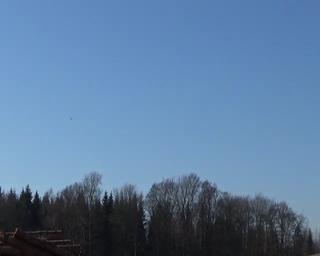

Denoised Image (Non-Local Means):


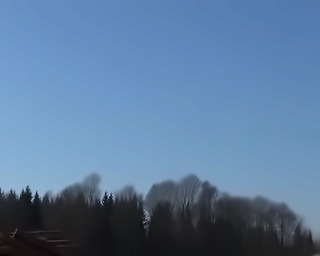

In [13]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # For displaying images in Colab

def denoise_image_nlm(image_path, h=3, h_color=3, templateWindowSize=7, searchWindowSize=21):
    """
    Applies Non-Local Means denoising to an image.

    Args:
        image_path (str): Path to the input image.
        h (float): Parameter regulating filter strength for luminance component.
                   Higher value removes more noise but may blur details.
        h_color (float): Parameter regulating filter strength for color components.
                         Usually the same as h.
        templateWindowSize (int): Size in pixels of the template patch that is used to compute weights.
                                 Should be odd. (default 7)
        searchWindowSize (int): Size in pixels of the window that is used to compute weighted average.
                                Should be odd. (default 21)

    Returns:
        numpy.ndarray: Denoised image.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Apply non-local means denoising
    # For color images, use cv2.fastNlMeansDenoisingColored
    denoised_img = cv2.fastNlMeansDenoisingColored(
        img, None, h, h_color, templateWindowSize, searchWindowSize
    )
    return denoised_img

# --- Example Usage ---
print("Demonstrating Non-Local Means Denoising on a sample image...")

# Get a sample image path from the registered dataset (e.g., from the training set)
sample_dataset_dicts = DatasetCatalog.get("my_dataset_train")
if sample_dataset_dicts:
    sample_image_path = sample_dataset_dicts[0]["file_name"]
    print(f"Original image path: {sample_image_path}")

    # Denoise the image
    denoised_sample_img = denoise_image_nlm(sample_image_path, h=10, h_color=10) # Adjust h and h_color as needed

    if denoised_sample_img is not None:
        original_img = cv2.imread(sample_image_path)

        print("Original Image:")
        cv2_imshow(original_img)
        print("Denoised Image (Non-Local Means):")
        cv2_imshow(denoised_sample_img)
else:
    print("No datasets registered to pick a sample image from for denoising demonstration.")


### Integrating Denoising into Detectron2 Pipeline

To apply this denoising consistently during training, you would typically integrate it into a custom `DatasetMapper` for Detectron2. A `DatasetMapper` is responsible for loading an image and its annotations, applying transformations (like resizing, augmentation, and in this case, denoising), and formatting the data for the model.

Here's a conceptual outline of how you would modify your Detectron2 configuration and potentially create a custom `DatasetMapper`:

1.  **Define a Custom `DatasetMapper`:** Create a Python class that inherits from `detectron2.data.DatasetMapper` (or a similar base). In its `__call__` method, you would load the image, apply the `denoise_image_nlm` function, and then apply other standard augmentations and transformations.

    ```python
    from detectron2.data import DatasetMapper
    from detectron2.data import build_detection_train_loader
    import copy # Required for deepcopy

    class CustomDenoisingDatasetMapper(DatasetMapper):
        def __init__(self, cfg, is_train=True):
            super().__init__(cfg, is_train)
            # You can customize augmentations here if needed
            # For example, disable default photo-metric augmentations if NLM handles it

        def __call__(self, dataset_dict):
            dataset_dict = copy.deepcopy(dataset_dict) # Don't modify original dict
            image_path = dataset_dict["file_name"]
            image = cv2.imread(image_path)

            # Apply denoising BEFORE other augmentations
            if image is not None:
                # Adjust h and h_color as hyper-parameters based on experimentation
                image = denoise_image_nlm(image_path, h=10, h_color=10)
                dataset_dict["image"] = image # Replace the original image with the denoised one
            else:
                print(f"Warning: Image not loaded for denoising: {image_path}")
                # Handle error or return original dataset_dict if image is missing

            # Apply other default Detectron2 transformations
            # This calls the parent's __call__ method to handle resizing, cropping, etc.
            return super().__call__(dataset_dict)

    # In your training code (cell d03c4cb8), you would set the custom mapper:
    # from detectron2.engine import DefaultTrainer
    # class Trainer(DefaultTrainer):
    #     @classmethod
    #     def build_train_loader(cls, cfg):
    #         return build_detection_train_loader(cfg, mapper=CustomDenoisingDatasetMapper(cfg, True))
    # trainer = Trainer(cfg)
    # trainer.resume_or_load(resume=False)
    # trainer.train()
    ```

2.  **Adjust `cfg.DATASETS.TRAIN`:** Ensure your training data loader uses this custom mapper. You might need to subclass `DefaultTrainer` to override its `build_train_loader` method.

Remember that applying denoising is a form of preprocessing. You will need to experiment with the `h` and `h_color` parameters of the NLM filter to find the optimal balance between noise reduction and detail preservation for your specific dataset.

### Configure and Train the Model

Now we'll configure a Detectron2 model. We'll use a pre-trained model from the Detectron2 model zoo as a starting point, which is common practice for fine-tuning on custom datasets. This example uses a Faster R-CNN model.

In [6]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

# Get a default configuration for a Faster R-CNN model
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

# Set dataset names
cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ("my_dataset_val",) # Use validation set for testing during training

# Number of classes
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(class_names) # Use the number of classes from your dataset

# Output directory for checkpoints and logs
cfg.OUTPUT_DIR = "./output/detectron2_custom_coco"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Learning rate, batch size, and number of iterations
cfg.SOLVER.IMS_PER_BATCH = 2 # Increase this if you have more GPU memory
cfg.SOLVER.BASE_LR = 0.00025 # Adjust learning rate
cfg.SOLVER.MAX_ITER = 300   # Number of training iterations
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml") # Load pre-trained weights

# Set evaluation period
cfg.TEST.EVAL_PERIOD = 100 # Evaluate every 100 iterations

print("Detectron2 config setup complete.")

# Create a trainer and start training
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

print("Detectron2 training complete!")
print(f"Model checkpoints and logs saved to: {cfg.OUTPUT_DIR}")

Detectron2 config setup complete.
[07/14 01:25:07 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
model_final_280758.pkl: 167MB [00:01, 104MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[07/14 01:25:10 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0714 01:25:13.681000 934 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbo

[07/14 01:25:21 d2.utils.events]:  eta: 0:01:45  iter: 19  total_loss: 1.136  loss_cls: 1.03  loss_box_reg: 0.02762  loss_rpn_cls: 0.06016  loss_rpn_loc: 0.02313    time: 0.3723  last_time: 0.3773  data_time: 0.0286  last_data_time: 0.0046   lr: 1.6068e-05  max_mem: 2109M
[07/14 01:25:34 d2.utils.events]:  eta: 0:01:37  iter: 39  total_loss: 0.7673  loss_cls: 0.6454  loss_box_reg: 0.04068  loss_rpn_cls: 0.02123  loss_rpn_loc: 0.01973    time: 0.3732  last_time: 0.3193  data_time: 0.0062  last_data_time: 0.0054   lr: 3.2718e-05  max_mem: 2109M
[07/14 01:25:42 d2.utils.events]:  eta: 0:01:30  iter: 59  total_loss: 0.3708  loss_cls: 0.2252  loss_box_reg: 0.05  loss_rpn_cls: 0.0339  loss_rpn_loc: 0.02136    time: 0.3785  last_time: 0.3213  data_time: 0.0060  last_data_time: 0.0062   lr: 4.9367e-05  max_mem: 2109M
[07/14 01:25:50 d2.utils.events]:  eta: 0:01:25  iter: 79  total_loss: 0.2209  loss_cls: 0.1154  loss_box_reg: 0.05254  loss_rpn_cls: 0.01618  loss_rpn_loc: 0.02386    time: 0.387

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[07/14 01:26:07 d2.utils.events]:  eta: 0:01:10  iter: 119  total_loss: 0.228  loss_cls: 0.09324  loss_box_reg: 0.07844  loss_rpn_cls: 0.0213  loss_rpn_loc: 0.01931    time: 0.3897  last_time: 0.3475  data_time: 0.0061  last_data_time: 0.0053   lr: 9.9318e-05  max_mem: 2109M
[07/14 01:26:15 d2.utils.events]:  eta: 0:01:02  iter: 139  total_loss: 0.1911  loss_cls: 0.075  loss_box_reg: 0.05808  loss_rpn_cls: 0.0196  loss_rpn_loc: 0.02151    time: 0.3924  last_time: 0.3825  data_time: 0.0072  last_data_time: 0.0057   lr: 0.00011597  max_mem: 2109M
[07/14 01:26:24 d2.utils.events]:  eta: 0:00:55  iter: 159  total_loss: 0.2089  loss_cls: 0.08435  loss_box_reg: 0.05739  loss_rpn_cls: 0.03229  loss_rpn_loc: 0.0159    time: 0.3952  last_time: 0.4448  data_time: 0.0062  last_data_time: 0.0063   lr: 0.00013262  max_mem: 2109M
[07/14 01:26:32 d2.utils.events]:  eta: 0:00:47  iter: 179  total_loss: 0.2195  loss_cls: 0.0957  loss_box_reg: 0.06087  loss_rpn_cls: 0.01408  loss_rpn_loc: 0.02348    tim

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[07/14 01:26:50 d2.utils.events]:  eta: 0:00:32  iter: 219  total_loss: 0.1969  loss_cls: 0.08881  loss_box_reg: 0.08101  loss_rpn_cls: 0.01604  loss_rpn_loc: 0.01037    time: 0.4031  last_time: 0.4171  data_time: 0.0071  last_data_time: 0.0088   lr: 0.00018257  max_mem: 2112M
[07/14 01:26:59 d2.utils.events]:  eta: 0:00:24  iter: 239  total_loss: 0.2465  loss_cls: 0.107  loss_box_reg: 0.1061  loss_rpn_cls: 0.01528  loss_rpn_loc: 0.009724    time: 0.4065  last_time: 0.4703  data_time: 0.0074  last_data_time: 0.0059   lr: 0.00019922  max_mem: 2112M
[07/14 01:27:07 d2.utils.events]:  eta: 0:00:16  iter: 259  total_loss: 0.2319  loss_cls: 0.1058  loss_box_reg: 0.1097  loss_rpn_cls: 0.008771  loss_rpn_loc: 0.005641    time: 0.4085  last_time: 0.4144  data_time: 0.0064  last_data_time: 0.0049   lr: 0.00021587  max_mem: 2112M
[07/14 01:27:16 d2.utils.events]:  eta: 0:00:08  iter: 279  total_loss: 0.2316  loss_cls: 0.09521  loss_box_reg: 0.09241  loss_rpn_cls: 0.009005  loss_rpn_loc: 0.009739

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


After training, the trained model weights and logs will be saved in the `cfg.OUTPUT_DIR` (e.g., `./output/detectron2_custom_coco`). You can then use the trained model for inference on new images or evaluate its performance on your test set.

## Evaluate the Trained Detectron2 Model

After training, it's crucial to evaluate the model's performance on a separate test set to understand how well it generalizes. We'll use the `COCOEvaluator` provided by Detectron2 to get standard object detection metrics.

In [9]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.modeling import build_model # Import build_model
from detectron2.checkpoint import DetectionCheckpointer # Import DetectionCheckpointer

# Re-using the 'cfg' from the training cell

# Set model weights path and testing threshold
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # Path to the last saved model
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.05  # Reduced testing threshold to capture more detections
cfg.DATASETS.TEST = ("my_dataset_test",) # Ensure we are evaluating on the test set

# Build the model from the configuration
model = build_model(cfg)
model.eval() # Set model to evaluation mode

# Load the trained weights into the model
checkpointer = DetectionCheckpointer(model)
checkpointer.load(cfg.MODEL.WEIGHTS)

# Create the COCO evaluator
evaluator = COCOEvaluator("my_dataset_test", output_dir=cfg.OUTPUT_DIR)

# Build the test data loader
val_loader = build_detection_test_loader(cfg, "my_dataset_test")

print("Starting model evaluation...")
# Run inference on the test dataset and get results
results = inference_on_dataset(model, val_loader, evaluator) # Pass the built and loaded model

print("Evaluation Results:")
print(results)

print(f"Detailed evaluation results saved to: {cfg.OUTPUT_DIR}")

[07/14 01:45:05 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/detectron2_custom_coco/model_final.pth ...
[07/14 01:45:05 d2.data.datasets.coco]: Loaded 8637 images in COCO format from dataset/split_dataset/test/RGB/coco_annotations.json
[07/14 01:45:06 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[07/14 01:45:06 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[07/14 01:45:06 d2.data.common]: Serializing 8637 elements to byte tensors and concatenating them all ...
[07/14 01:45:06 d2.data.common]: Serialized dataset takes 2.29 MiB
Starting model evaluation...
[07/14 01:45:06 d2.evaluation.evaluator]: Start inference on 8637 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[07/14 01:45:07 d2.evaluation.evaluator]: Inference done 11/8637. Dataloading: 0.0010 s/iter. Inference: 0.1039 s/iter. Eval: 0.0003 s/iter. Total: 0.1052 s/iter. ETA=0:15:07
[07/14 01:45:12 d2.evaluation.evaluator]: Inference done 58/8637. Dataloading: 0.0018 s/iter. Inference: 0.1045 s/iter. Eval: 0.0003 s/iter. Total: 0.1066 s/iter. ETA=0:15:14
[07/14 01:45:17 d2.evaluation.evaluator]: Inference done 103/8637. Dataloading: 0.0022 s/iter. Inference: 0.1062 s/iter. Eval: 0.0003 s/iter. Total: 0.1088 s/iter. ETA=0:15:28
[07/14 01:45:22 d2.evaluation.evaluator]: Inference done 148/8637. Dataloading: 0.0021 s/iter. Inference: 0.1078 s/iter. Eval: 0.0003 s/iter. Total: 0.1103 s/iter. ETA=0:15:36
[07/14 01:45:27 d2.evaluation.evaluator]: Inference done 190/8637. Dataloading: 0.0021 s/iter. Inference: 0.1100 s/iter. Eval: 0.0003 s/iter. Total: 0.1125 s/iter. ETA=0:15:50
[07/14 01:45:32 d2.evaluation.evaluator]: Inference done 232/8637. Dataloading: 0.0021 s/iter. Inference: 0.1117 s/iter. E

The `results` dictionary will contain various COCO metrics, including Average Precision (AP) for different Intersection over Union (IoU) thresholds and object sizes. This will give you a comprehensive understanding of your model's performance.

### Summary of Detectron2 Model Evaluation Results

The evaluation results provide a detailed breakdown of the model's performance using COCO metrics. Here's an interpretation:

**Overall Average Precision (AP):**

*   **`AP: 4.440`**: This is the primary COCO metric, representing the Average Precision across all Intersection over Union (IoU) thresholds (from 0.5 to 0.95, with steps of 0.05) and all categories. A value of 4.44% is quite low, indicating that the model has significant room for improvement in accurately detecting objects.

**AP at Specific IoU Thresholds:**

*   **`AP50: 16.479`**: Average Precision at an IoU threshold of 0.50. This means if a predicted bounding box overlaps with a ground truth box by at least 50%, it's considered a correct detection. This value (16.48%) is higher than the overall AP, suggesting that when the criterion for "correct detection" is less strict, the model performs relatively better.
*   **`AP75: 0.474`**: Average Precision at an IoU threshold of 0.75. This is a stricter metric, requiring a 75% overlap. The very low value (0.47%) here shows that the model struggles to produce highly precise bounding box detections.

**AP by Object Size:**

*   **`APs: 4.330`**: Average Precision for **small** objects (area < 32^2 pixels).
*   **`APm: 21.098`**: Average Precision for **medium** objects (32^2 < area < 96^2 pixels).
*   **`APl: nan`**: Average Precision for **large** objects (area > 96^2 pixels). `nan` (Not a Number) here likely indicates that there were no large objects in the test dataset or no large objects were detected by the model.
    *   The model appears to perform best on medium-sized objects (`APm`), which is noteworthy given the overall low AP. Its performance on small objects (`APs`) is similar to the overall AP.

**Per-Category AP:**

*   **`AP-drone: 0.638`**: Average Precision for the 'drone' class (0.64%).
*   **`AP-bird: 8.243`**: Average Precision for the 'bird' class (8.24%).
    *   The model performs significantly better at detecting 'bird' objects compared to 'drone' objects. This difference could stem from varying numbers of training examples, more distinct features for birds, or drones being inherently more challenging to detect in this specific dataset (e.g., due to size, occlusion, or visual similarity to background).

**In Conclusion:**

This model's overall AP of **4.44%** is quite low. While it can detect some objects with moderate overlap (`AP50`), it faces challenges with precise localization (`AP75`) and shows a notable disparity in performance between classes (better for 'bird' than 'drone'). The `APl` being `nan` should be investigated further to confirm the presence of large objects in the dataset; if they exist, it suggests a complete failure of detection for this size category.

## Analyzing Error Sources:

One potential source of error comes from the shot noise present in each image. In the next training iteration, we need a way of getting rid of shot noise to avoid confusing the model. We should also randomly augment the the training data to make the model robust to adverse conditions.